# 과제3: 정규분포 난수로 히스토그램 만들기 (팬시 인덱싱과 브로드캐스팅 활용)
- 목표: 난수를 생성하고, 직접 구간에 속하는 인덱스를 계산하여 히스토그램을 생성. np.searchsorted를 사용하지 않고 각 값이 어느 구간에 속하는지 확인.

## 구현 순서:

### 1. 난수 생성:
- 평균이 0, 표준편차가 1인 정규분포에서 난수 10,000개를 생성하여 data 배열에 저장.

In [45]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "D2Coding"
plt.rcParams["axes.unicode_minus"] = False

In [46]:
np.random.seed(42)
N = 10_000
data = np.random.normal(0.0, 1.0, size=N)


### 2. 구간 설정:
- -10에서 10까지 20개의 구간을 균등하게 나누어 bins 배열.
이 구간들은 히스토그램의 각 구간 경계.

In [47]:
bins = np.linspace(-10, 10, 21)
nbins = len(bins) - 1
bin_width = float(bins[1] - bins[0])

### 3. 구간 인덱스 계산:
- data의 각 값이 어느 구간에 속하는지 직접 계산하여 구간 인덱스 배열 indices에 저장.
- 예를 들어, data의 값이 특정 구간에 속하면 indices 배열에 그 구간 인덱스를 기록합니다.
- 이 과정에서 브로드캐스팅과 팬시 인덱싱을 활용하여 효율적으로 구간 인덱스를 계산.

In [48]:
upper_safe = np.nextafter(bins[-1], bins[0])
data_clipped = np.clip(data, bins[0], upper_safe)
mask = (data_clipped[:, None] >= bins[:-1]) & (data_clipped[:, None] < bins[1:])
indices = mask.argmax(axis=1)

### 4. 누적 카운팅:
- 구한 indices 값을 사용하여, 각 구간별로 카운트를 계산.
- 팬시 인덱싱을 통해 indices에 해당하는 counts 위치에 1씩 누적.

In [49]:
counts = np.zeros(nbins, dtype=int)
np.add.at(counts, indices, 1)

### 5. 결과 시각화:
- 구간별 빈도수를 그래프로 시각화하여 히스토그램.
- bins와 counts를 사용하여 히스토그램이 올바르게 그려졌는지 확인.

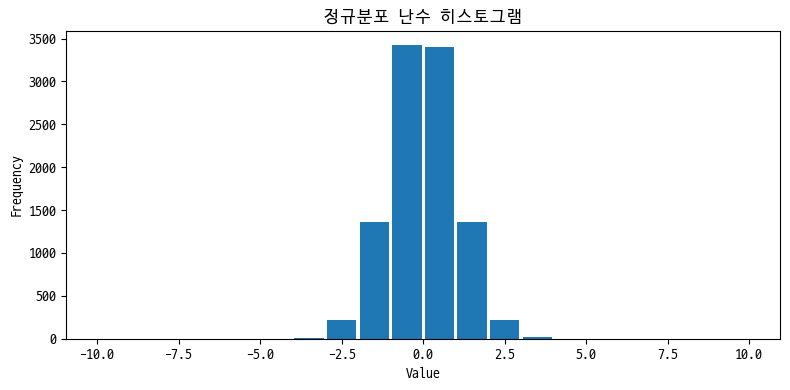

In [50]:
centers = (bins[:-1] + bins[1:]) / 2
centers = np.asarray(centers, dtype=float)
counts = np.asarray(counts, dtype=float)
plt.figure(figsize=(8, 4))
plt.bar(centers, counts, width=bin_width * 0.9, align='center')
plt.title("정규분포 난수 히스토그램")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()